In [1]:
import pickle
import numpy as np

pkl_path = r"U:\YuanqiHua\High speed\260123 wt1 MTZ\AVI_out\wt1-MTZ-control-1_7.pkl"

with open(pkl_path, "rb") as f:
    tf = pickle.load(f)

print("Type:", type(tf))
print("Length (frames):", len(tf))
print("Shape:", np.array(tf).shape)
print("First frame:\n", tf[0])
print("Last frame:\n", tf[-1])


Type: <class 'list'>
Length (frames): 277
Shape: (277, 20, 2)
First frame:
 [[678.  42.]
 [677.  79.]
 [671. 116.]
 [672. 153.]
 [674. 190.]
 [671. 227.]
 [669. 264.]
 [662. 300.]
 [662. 337.]
 [657. 374.]
 [656. 411.]
 [656. 448.]
 [654. 485.]
 [650. 522.]
 [647. 559.]
 [645. 596.]
 [644. 633.]
 [641. 670.]
 [639. 707.]
 [638. 744.]]
Last frame:
 [[681.  41.]
 [683.  78.]
 [677. 115.]
 [678. 152.]
 [680. 189.]
 [680. 226.]
 [675. 263.]
 [668. 299.]
 [668. 336.]
 [663. 373.]
 [659. 410.]
 [656. 447.]
 [654. 484.]
 [647. 520.]
 [644. 557.]
 [642. 594.]
 [641. 631.]
 [638. 668.]
 [636. 705.]
 [635. 742.]]


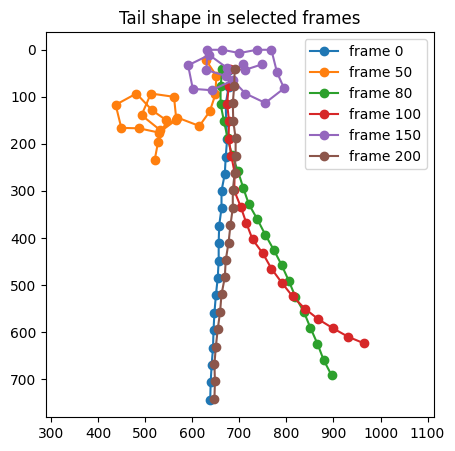

In [8]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

pkl_path = r"U:\YuanqiHua\High speed\260123 wt1 MTZ\AVI_out\wt1-MTZ-control-1_7.pkl"

with open(pkl_path, "rb") as f:
    tf = np.array(pickle.load(f))

frames_to_plot = [0, 50,80, 100, 150,200]

plt.figure(figsize=(5, 5))
for fr in frames_to_plot:
    pts = tf[fr]
    plt.plot(pts[:, 0], pts[:, 1], "-o", label=f"frame {fr}")

plt.gca().invert_yaxis()  # 因为图像坐标
plt.axis("equal")
plt.legend()
plt.title("Tail shape in selected frames")
plt.show()

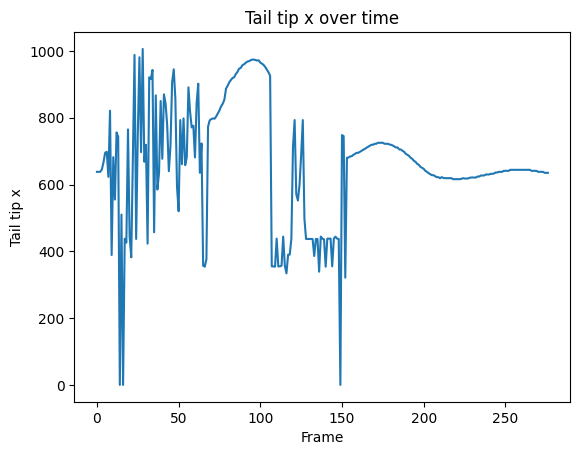

In [3]:
tailtip_x = tf[:, -1, 0]

plt.figure()
plt.plot(tailtip_x)
plt.xlabel("Frame")
plt.ylabel("Tail tip x")
plt.title("Tail tip x over time")
plt.show()


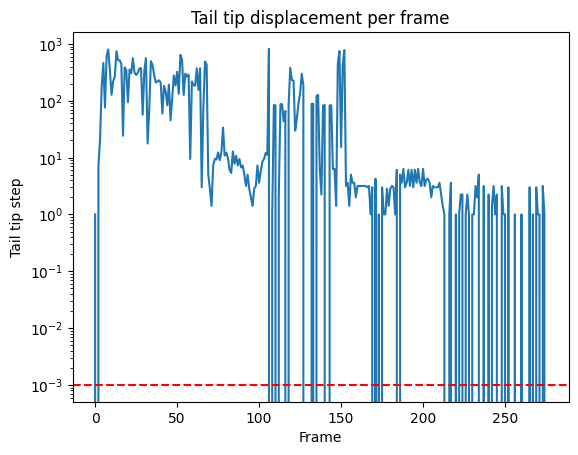

Fraction near zero: 0.15942028985507245


In [4]:
import numpy as np

tip = tf[:, -1, :]
step = np.linalg.norm(np.diff(tip, axis=0), axis=1)

plt.figure()
plt.plot(step)
plt.axhline(1e-3, color="r", linestyle="--")
plt.yscale("log")
plt.xlabel("Frame")
plt.ylabel("Tail tip step")
plt.title("Tail tip displacement per frame")
plt.show()

print("Fraction near zero:", np.mean(step < 1e-3))

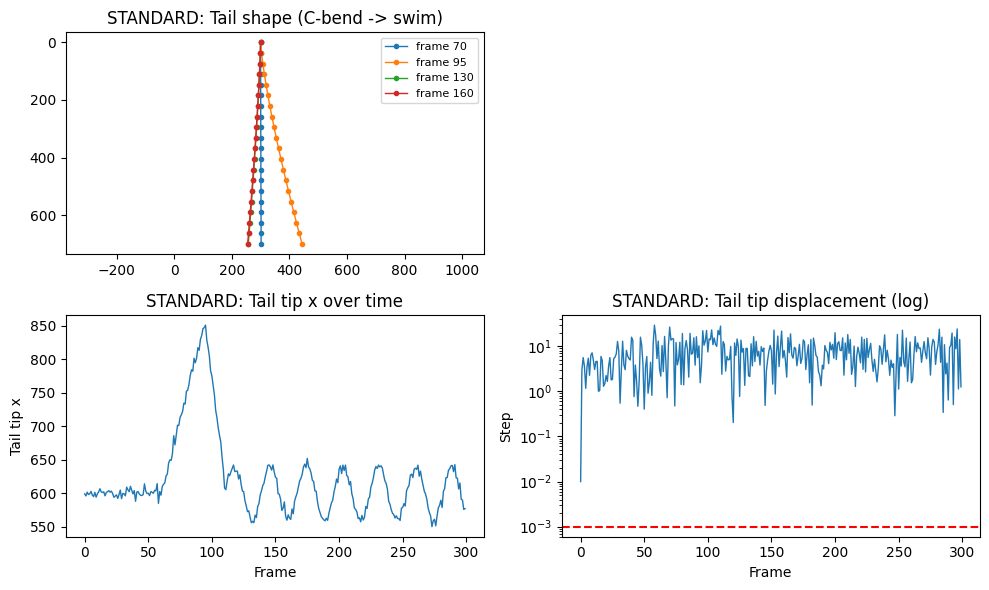

In [9]:
# example

import numpy as np
import matplotlib.pyplot as plt

# --- simulate a "good" bout: C-bend then left-right swimming ---
fps = 1000
T = 300
t = np.arange(T)

# tailtip x: big one-sided deflection (C-bend) then oscillation
x = np.zeros(T, float)
x[:60] = 0.0
x[60:95] = np.linspace(0, 250, 35)         # rapid bend
x[95:110] = np.linspace(250, 40, 15)       # recovery
x[110:] = 40*np.sin(2*np.pi*35*(t[110:]-110)/fps)  # ~35 Hz oscillation
x += 5*np.random.randn(T)                  # small noise

# displacement ~ abs(dx)
step = np.abs(np.diff(x, prepend=x[0])) + 1e-2

# Tail shapes: generate a smooth centerline for a few frames
def tail_shape(frame, n_points=20):
    s = np.linspace(0, 1, n_points)
    # curvature control: big C at frame~95, else oscillatory
    if frame < 110:
        A = 0.8 * np.exp(-((frame-95)/12)**2)  # C-bend bump
    else:
        A = 0.25*np.sin(2*np.pi*35*(frame-110)/fps)
    # generate curve in (x,y)
    y = 700*s
    xcurve = 300 + 180*A*(s**1.3)              # bend increases toward tip
    return xcurve, y

frames_to_plot = [70, 95, 130, 160]

plt.figure(figsize=(10,6))

ax1 = plt.subplot(2,2,1)
for fr in frames_to_plot:
    xx, yy = tail_shape(fr)
    ax1.plot(xx, yy, "-o", ms=3, lw=1, label=f"frame {fr}")
ax1.invert_yaxis()
ax1.axis("equal")
ax1.set_title("STANDARD: Tail shape (C-bend -> swim)")
ax1.legend(fontsize=8)

ax2 = plt.subplot(2,2,3)
ax2.plot(x+600, lw=1)  # shift just for visual
ax2.set_title("STANDARD: Tail tip x over time")
ax2.set_xlabel("Frame"); ax2.set_ylabel("Tail tip x")

ax3 = plt.subplot(2,2,4)
ax3.plot(step, lw=1)
ax3.axhline(1e-3, ls="--", color="r")
ax3.set_yscale("log")
ax3.set_title("STANDARD: Tail tip displacement (log)")
ax3.set_xlabel("Frame"); ax3.set_ylabel("Step")

plt.tight_layout()
plt.show()


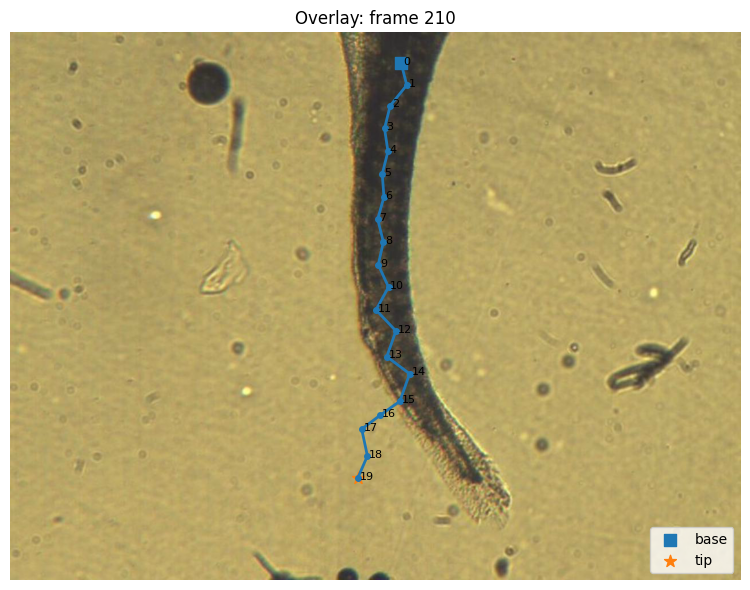

In [16]:
import pickle
import numpy as np
import cv2
import matplotlib.pyplot as plt

def load_tf(pkl_path):
    with open(pkl_path, "rb") as f:
        tf = pickle.load(f)
    return np.asarray(tf, dtype=float)

def read_frame_from_avi(avi_path, frame_idx=0):
    cap = cv2.VideoCapture(avi_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video: {avi_path}")

    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
    ok, frame_bgr = cap.read()
    cap.release()

    if not ok:
        raise RuntimeError(f"Cannot read frame {frame_idx} from {avi_path}")

    # Convert BGR->RGB for matplotlib
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    return frame_rgb

def overlay_tail_on_frame(frame_rgb, pts_xy, title="", invert_y=False, show_index=False):
    """
    frame_rgb: (H,W,3) uint8 RGB
    pts_xy: (N,2) [x,y] in image pixel coords
    invert_y: if True, invert y-axis (usually False when using imshow)
    """
    pts = np.asarray(pts_xy, float)

    plt.figure(figsize=(8, 6))
    plt.imshow(frame_rgb)
    plt.plot(pts[:,0], pts[:,1], "-o", ms=4, lw=2)

    # mark base and tip
    plt.scatter([pts[0,0]], [pts[0,1]], s=80, marker="s", label="base")
    plt.scatter([pts[-1,0]], [pts[-1,1]], s=80, marker="*", label="tip")

    if show_index:
        for i, (x, y) in enumerate(pts):
            plt.text(x+3, y+3, str(i), fontsize=8)

    plt.title(title)
    plt.axis("off")
    plt.legend(loc="lower right")

    # IMPORTANT:
    # matplotlib imshow uses image coordinates (origin at top-left by default),
    # so normally you should NOT invert y here.
    if invert_y:
        plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.show()

# ----------------- 示例用法 -----------------
pkl_path = r"U:\YuanqiHua\High speed\260123 wt1 MTZ\pkl_output\wt1-MTZ-1_0.pkl"
avi_path = r"U:\YuanqiHua\High speed\260123 wt1 MTZ\AVI_out\wt1-MTZ-1_0.avi"

tf = load_tf(pkl_path)

frame_idx = 210  # 你想看的帧
frame_rgb = read_frame_from_avi(avi_path, frame_idx)
pts = tf[frame_idx]  # (20,2)

overlay_tail_on_frame(
    frame_rgb,
    pts,
    title=f"Overlay: frame {frame_idx}",
    show_index=True
)


In [2]:
import sys, cv2
print("PYTHON:", sys.executable)
print("OPENCV:", cv2.__version__)
print("HAS XIMGPROC:", hasattr(cv2, "ximgproc"))



PYTHON: C:\Users\huayuanqi\AppData\Local\Programs\Python\Python310\python.exe
OPENCV: 4.12.0
HAS XIMGPROC: False
